<a href="https://colab.research.google.com/github/thofaa/cosine_similarity_tf-idf_approach/blob/main/textgeneration_markovchain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---


# **TEXT GENERATION USING MARKOV CHAIN METHOD**


---

# **Preprocess step**

In [ ]:
#in this step we have 2 important variable
#1. transitionprob, {string: {string:probability, ...}, ...}
#2. tokenindex, {string: index, ...}

#in the next step these two variables will be combined
#3. transition_model, {outer index: {inner index: probability, ...}, ...} --> it will be inputed into markov chain model as trained data
#each outer index will have connection to inner index as many as the cardinality, in this case connec to 428 different indexes

#FURTHERMORE IMPROVEMENT!
#only using 2 variables, x and y
#x --> {string: index, ...}
#y --> {outer index: {inner index: probability, ...}, ...}

In [ ]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 32.2 MB/s eta 0:00:00


In [ ]:
import nltk
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.models import MarkovChain as mc
from pgmpy.factors.discrete import State
import random as rd
from fractions import Fraction

In [ ]:
#open, read, and tokenize the text
nltk.download('punkt_tab')
with open('Hidden Markov Models Trained Data.txt', 'r') as p:
  text_content = p.read()
traineddata = nltk.tokenize.word_tokenize(text=text_content) #[token1, token2, ...]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
#give each token a tag
nltk.download('averaged_perceptron_tagger_eng')
tagdata = nltk.tag.pos_tag(traineddata) #[(token, tag), ...]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
#give each token an index as prerequisite before jump into training a markov chain model
tokenindex = {}

#record unique token and each token will be given an index
for i in range(len(traineddata)):
  if traineddata[i] not in tokenindex:
    tokenindex.update({traineddata[i]:i})

#update the index so that into ascending order unique index
num = 0
for key in tokenindex.keys():
  tokenindex.update({key:num})
  num += 1

tokenindex

{'Hidden': 0,
 'Markov': 1,
 'Models': 2,
 'are': 3,
 'probabilistic': 4,
 'models': 5,
 'used': 6,
 'to': 7,
 'solve': 8,
 'real': 9,
 'life': 10,
 'problems': 11,
 'ranging': 12,
 'from': 13,
 'something': 14,
 'everyone': 15,
 'thinks': 16,
 'about': 17,
 'at': 18,
 'least': 19,
 'once': 20,
 'a': 21,
 'week': 22,
 '—': 23,
 'how': 24,
 'is': 25,
 'the': 26,
 'weather': 27,
 'going': 28,
 'be': 29,
 'like': 30,
 'tomorrow': 31,
 '?': 32,
 'hard': 33,
 'molecular': 34,
 'biology': 35,
 ',': 36,
 'such': 37,
 'as': 38,
 'predicting': 39,
 'peptide': 40,
 'binders': 41,
 'human': 42,
 'MHC': 43,
 'class': 44,
 'II': 45,
 'molecule': 46,
 '.': 47,
 'close': 48,
 'relatives': 49,
 'of': 50,
 'Chains': 51,
 'but': 52,
 'their': 53,
 'hidden': 54,
 'states': 55,
 'make': 56,
 'them': 57,
 'unique': 58,
 'tool': 59,
 'use': 60,
 'when': 61,
 'you': 62,
 '’': 63,
 're': 64,
 'interested': 65,
 'in': 66,
 'determining': 67,
 'probability': 68,
 'sequence': 69,
 'random': 70,
 'variables': 71,

In [ ]:
#map each two tokens (current token and next token) and measure a transition probability of each the connection
transitionprob = {}

for i in range(len(tagdata)):
  if i == len(tagdata)-2:
    break

  currchar = tagdata[i][0]
  nextchar = tagdata[i+1][0]

  if currchar not in transitionprob:
    transitionprob[currchar]={nextchar:(1,1)} #{'x1':{'x2':n}}
  else:
    if nextchar in transitionprob[currchar]:
      for key, value in transitionprob[currchar].items():
        numprob, denomprob = value
        transitionprob[currchar].update({key:(numprob, denomprob + 1)}) #each exist character numerator doesn't update, just denominator
      numchar = transitionprob[currchar][nextchar][0]
      transitionprob[currchar].update({nextchar:(numchar +1, denomprob +1)}) #update numerator alongside denominator of related character that has been exist
    else:
      for key, value in transitionprob[currchar].items():
        numprob, denomprob = value
        transitionprob[currchar].update({key:(numprob, denomprob + 1)}) #each exist character numerator doesn't update, just denominator
      transitionprob[currchar].update({nextchar:(1, denomprob + 1)}) #numerator = 1 since the next character doesn't exist in related dict

#THIS CODE BELOW STILL NEEDS FURTHERMORE IMPROVEMENT!

#change the numerator & denom into fraction
for currchar, targets in transitionprob.items(): #item([currchar, targets]), (targets>1):={nextchar:(weight), ...}
  for nextchar, (numerator, denominator) in targets.items():
    prob = Fraction(numerator, denominator)
    transitionprob[currchar].update({nextchar:prob})

In [ ]:
transitionprob

{'Hidden': {'Markov': 0.9090909090909091, 'States': 0.09090909090909091},
 'Markov': {'Models': 0.3,
  'Chains': 0.05,
  'Model': 0.15,
  'Chain': 0.35,
  'Assumption': 0.1,
  'model': 0.05},
 'Models': {'are': 0.3333333333333333,
  'into': 0.16666666666666666,
  ',': 0.16666666666666666,
  'describe': 0.16666666666666666,
  'fresh': 0.16666666666666666},
 'are': {'probabilistic': 0.05263157894736842,
  'close': 0.05263157894736842,
  'statistical': 0.05263157894736842,
  'the': 0.10526315789473684,
  'dependent': 0.10526315789473684,
  'hidden': 0.10526315789473684,
  'processes': 0.05263157894736842,
  'traversed': 0.05263157894736842,
  'in': 0.05263157894736842,
  'now': 0.05263157894736842,
  'several': 0.05263157894736842,
  'directly': 0.05263157894736842,
  'those': 0.05263157894736842,
  'simply': 0.05263157894736842,
  'all': 0.05263157894736842,
  'they': 0.05263157894736842},
 'probabilistic': {'models': 0.3333333333333333,
  'systems': 0.3333333333333333,
  'process': 0.33

In [ ]:
#probability of out going node is always one, this will check each outgoing prob
num = 0
for currchar, targets in transitionprob.items():
  total = 0
  for nextchar, prob in targets.items():
    total += prob
  if abs(1-total) != 0:
    print(total)
    num += 1
print(f'Total that doesnt have total of one: {num}')

Total that doesnt have total of one: 0


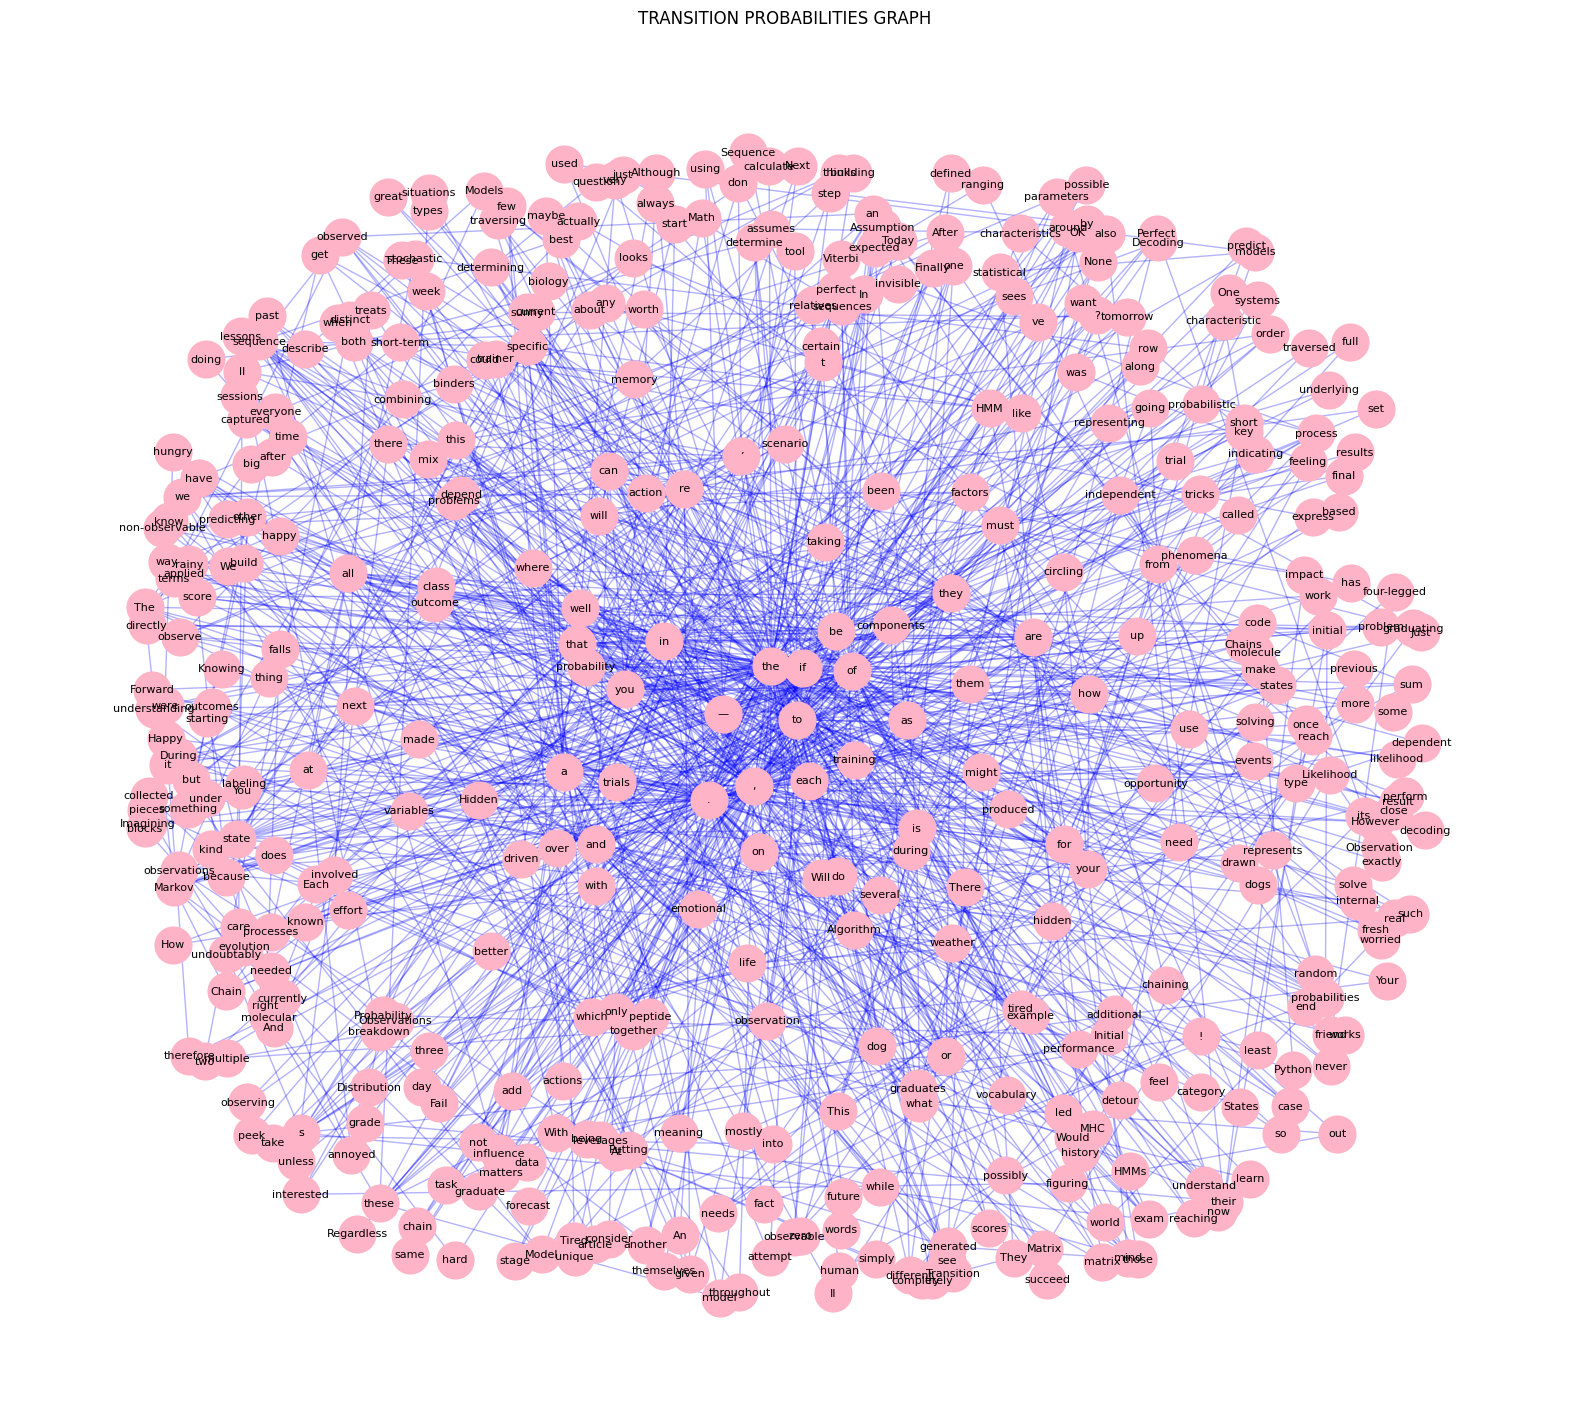

In [ ]:
graph=nx.Graph()

for initialnode, targets in transitionprob.items():
  for nextnode, prob in targets.items():
    graph.add_edge(initialnode, nextnode, weight=prob)

plt.figure(figsize=(20,18))
pos = nx.spring_layout(graph, k=0.3, iterations=17)
nx.draw_networkx_nodes(graph, pos, node_size=700, node_color='#ffb3c6')
nx.draw_networkx_labels(graph, pos, font_size=8, font_family='sans-serif')

edges = graph.edges(data=True)
nx.draw_networkx_edges(graph, pos, edgelist=edges, alpha=0.3, edge_color='b')

'''
edge_labels = nx.get_edge_attributes(graph, name='weight')
edge_labels = {k:f'{v:.2f}' for k, v in edge_labels.items()} #weight:prob
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=6)'''

plt.title('TRANSITION PROBABILITIES GRAPH')
plt.axis('off')
plt.show()

In [ ]:
cardinalities = len(tokenindex)
cardinalities

428

In [ ]:
transition_model = {}
for start, targets in transitionprob.items():
  currindex = tokenindex[start] #result: a current index
  for end, prob in targets.items():
    nextindex = tokenindex[end] #result: a next index
    # Convert Fraction to float here
    prob_float = float(prob)
    if currindex not in transition_model: #check index
      transition_model[currindex]={nextindex:prob_float} #{0:{0:0.5}}
    else:
      transition_model[currindex].update({nextindex:prob_float})

#fill remaining gap as many as the related cardinality
for i in range(cardinalities):
  if i not in transition_model:
    # If state 'i' had no observed outgoing transitions, initialize with 0.0 for all states
    # This will be normalized later.
    transition_model[i] = {j: 0.0 for j in range(cardinalities)}

  #fill in missing transitions to 'j' with probability 0
  for j in range(cardinalities):
    if j not in transition_model[i]:
      transition_model[i].update({j:0.0})

##THIS CODE BELOW STILL NEEDS FURTHERMORE IMPROVEMENT!

# Ensure the sum of probabilities for each state is exactly 1.0
for i in range(cardinalities):
    current_sum = sum(transition_model[i].values())
    # If the sum is 0.0 (meaning the state had no observed outgoing transitions),
    # distribute probability uniformly among all states to encourage diversity.
    if current_sum == 0.0:
        uniform_prob = 1.0 / cardinalities
        for j in range(cardinalities):
            transition_model[i][j] = uniform_prob
    # Otherwise, normalize if the sum is not exactly 1.0 due to floating point inaccuracies
    elif not (abs(current_sum - 1.0) < 1e-9):
        factor = 1.0 / current_sum
        for j in transition_model[i]:
            transition_model[i][j] *= factor

# Diagnostic print statement
print(f"Transition probabilities for 'works' (index {tokenindex.get('works', 'N/A')}): {transition_model.get(tokenindex.get('works'), 'Not found')}")

Transition probabilities for 'works' (index 427): {0: 0.002336448598130841, 1: 0.002336448598130841, 2: 0.002336448598130841, 3: 0.002336448598130841, 4: 0.002336448598130841, 5: 0.002336448598130841, 6: 0.002336448598130841, 7: 0.002336448598130841, 8: 0.002336448598130841, 9: 0.002336448598130841, 10: 0.002336448598130841, 11: 0.002336448598130841, 12: 0.002336448598130841, 13: 0.002336448598130841, 14: 0.002336448598130841, 15: 0.002336448598130841, 16: 0.002336448598130841, 17: 0.002336448598130841, 18: 0.002336448598130841, 19: 0.002336448598130841, 20: 0.002336448598130841, 21: 0.002336448598130841, 22: 0.002336448598130841, 23: 0.002336448598130841, 24: 0.002336448598130841, 25: 0.002336448598130841, 26: 0.002336448598130841, 27: 0.002336448598130841, 28: 0.002336448598130841, 29: 0.002336448598130841, 30: 0.002336448598130841, 31: 0.002336448598130841, 32: 0.002336448598130841, 33: 0.002336448598130841, 34: 0.002336448598130841, 35: 0.002336448598130841, 36: 0.00233644859813084

In [ ]:
len(transition_model)

428

# **Training and Generating**

In [ ]:
modelmc = mc() #initialize empty markov chain model
modelmc.add_variable(variable='intro_hmm', card=cardinalities)

In [ ]:
modelmc.add_transition_model(variable='intro_hmm', transition_model=transition_model)

In [ ]:
# Create a reverse mapping from index to word
indextoword = {index: word for word, index in tokenindex.items()}

sampled_indices_df = modelmc.sample(size=200)
sampled_indices = sampled_indices_df['intro_hmm'].tolist()

# Convert indices back to words
sampled_words = [indextoword[idx] for idx in sampled_indices]

# Join the words to form a sentence (or multiple sentences if it makes sense semantically)
# For simplicity, we'll join all sampled words with spaces for now.
sentence = ' '.join(sampled_words)

print("\nGenerated Sentence:")
print(sentence)


Generated Sentence:
is that the Markov Chain , or the only if your dog ’ s undoubtably a Markov Chain , along with a Hidden Markov Chain . This kind of random variables — a Likelihood Matrix , being generated them to one . This matrix , being completely independent from one of an observable process and graduate with the exam . One example is captured in . Your dog treats involved , the trainer only sees the probability of observations and take a probabilistic process because they feeling during the future ! With Hidden Markov Models into how you want is the next , your dog training lessons for short , and graduate with an HMM could express how you need to determine the end of observable events , which themselves , OK — a few actions or sunny tomorrow , is only dependent on your dog will set the scores of observations , all you ’ ll be applied to determine the Hidden Markov Models into how is predicting peptide binders to hard molecular biology problems , unless there are dependent on 

In [ ]:
#Generated Sentence:

'''
is that the Markov Chain , or the only if your dog ’ s undoubtably a Markov Chain ,
along with a Hidden Markov Chain . This kind of random variables — a Likelihood Matrix ,
being generated them to one . This matrix , being completely independent from one of an observable process and graduate with the exam .
One example is captured in . Your dog treats involved , the trainer only sees the
probability of observations and take a probabilistic process because they feeling during the future !
With Hidden Markov Models into how you want is the next , your dog training lessons for short ,
and graduate with an HMM could express how you need to determine the end of observable events ,
which themselves , OK — a few actions or sunny tomorrow ,
is only dependent on your dog will set the scores of observations ,
all you ’ ll be applied to determine the Hidden Markov Models into how is predicting peptide binders to hard molecular biology problems ,
unless there are dependent on internal factors that each specific sequence of the only consider if your dog very well as the score
'''